In [70]:
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
import requests
from io import StringIO as sio
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import re
import itertools
import sys
import baltic as bt
import random
from collections import Counter
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np
import seaborn as sns

In [71]:
# for avian NA div analysis 

NA_div = {}

with open(f'avian.json', "r") as file:
    data = json.load(file)

for name, node_data in data["nodes"].items():
    
    # only consider nodes that list NA as a high support reassorting segment
    
    if "NA" in node_data.get("segments", ""):
        
        divergence_str = node_data.get("divergence", "")
        
        # only extract the divergence value for NA
        
        match = re.search(r"NA\((\d+)\)", divergence_str)
        
        NA_div[name] = int(match.group(1))

print(len(NA_div))


173


type
leaf    94
node    79
Name: count, dtype: int64


/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


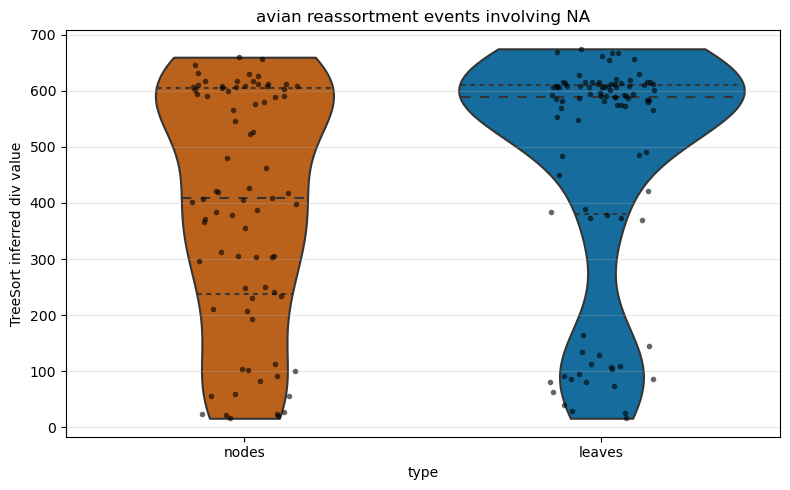

In [72]:

df = pd.DataFrame(list(NA_div.items()), columns=["name", "divergence"])

# node or a leaf
df["type"] = df["name"].apply(lambda x: "node" if x.startswith("NODE_") else "leaf")
counts = df["type"].value_counts()
print(counts)

plt.figure(figsize=(8, 5))

colors = {"leaf": "#0072B2", "node": "#D55E00"}  # colorblind-friendly

sns.violinplot(
    x="type",
    y="divergence",
    data=df,
    palette=colors,
    inner="quartile",
    cut=0,
    order=["node", "leaf"]
)

sns.stripplot(
    x="type",
    y="divergence",
    data=df,
    color="k",           
    size=4,
    jitter=0.15,         
    alpha=0.6,
    order=["node", "leaf"]
)

plt.xticks([0, 1], ["nodes", "leaves"])
plt.ylabel("TreeSort inferred div value")
plt.title("avian reassortment events involving NA")
plt.grid(True, alpha=0.3, axis="y")


plt.tight_layout()
plt.show()


/var/folders/b4/087mzk6d6sj828w5t9xtml640000gr/T/ipykernel_95948/256417598.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


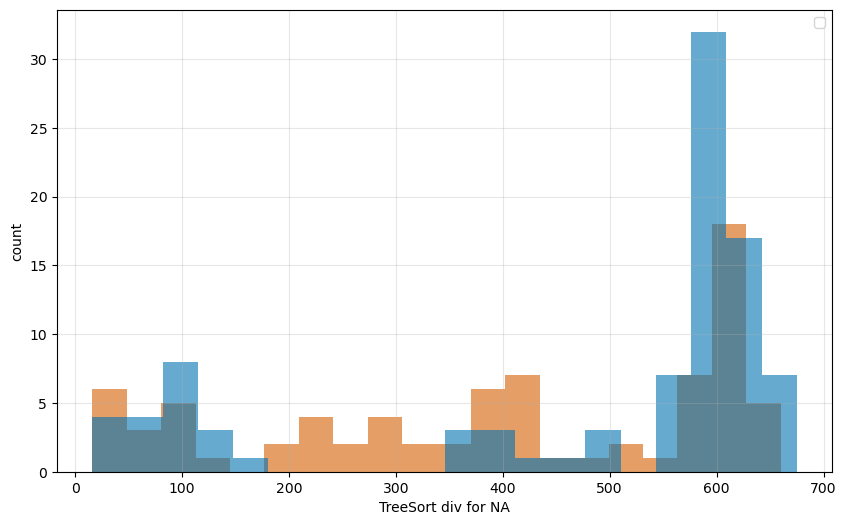

In [73]:
colors = {"leaf": "#0072B2", "node": "#D55E00"}  # same as before

plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df['type'] == 'node', 'divergence'],
    bins=20,
    alpha=0.6,
    color=colors['node']
)

plt.hist(
    df.loc[df['type'] == 'leaf', 'divergence'],
    bins=20,
    alpha=0.6,
    color=colors['leaf']
)

plt.xlabel("TreeSort div for NA")
plt.ylabel("count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [74]:
# what about for other segments?

segments = ["PB2", "PB1", "PA", "NP", "MP", "NS"]

segment_divs = {seg: {} for seg in segments}

with open("avian.json", "r") as file:
    data = json.load(file)

for name, node_data in data["nodes"].items():
    
    divergence_str = node_data.get("divergence", "")

    for seg in segments:
        
        match = re.search(rf"{seg}\((\d+)\)", divergence_str)
        
        if not match:
            continue

        segment_divs[seg][name] = int(match.group(1))

for seg, seg_dict in segment_divs.items():
    print(f"{seg}: {len(seg_dict)} reassortment events")


PB2: 117 reassortment events
PB1: 111 reassortment events
PA: 183 reassortment events
NP: 131 reassortment events
MP: 99 reassortment events
NS: 100 reassortment events


/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na o

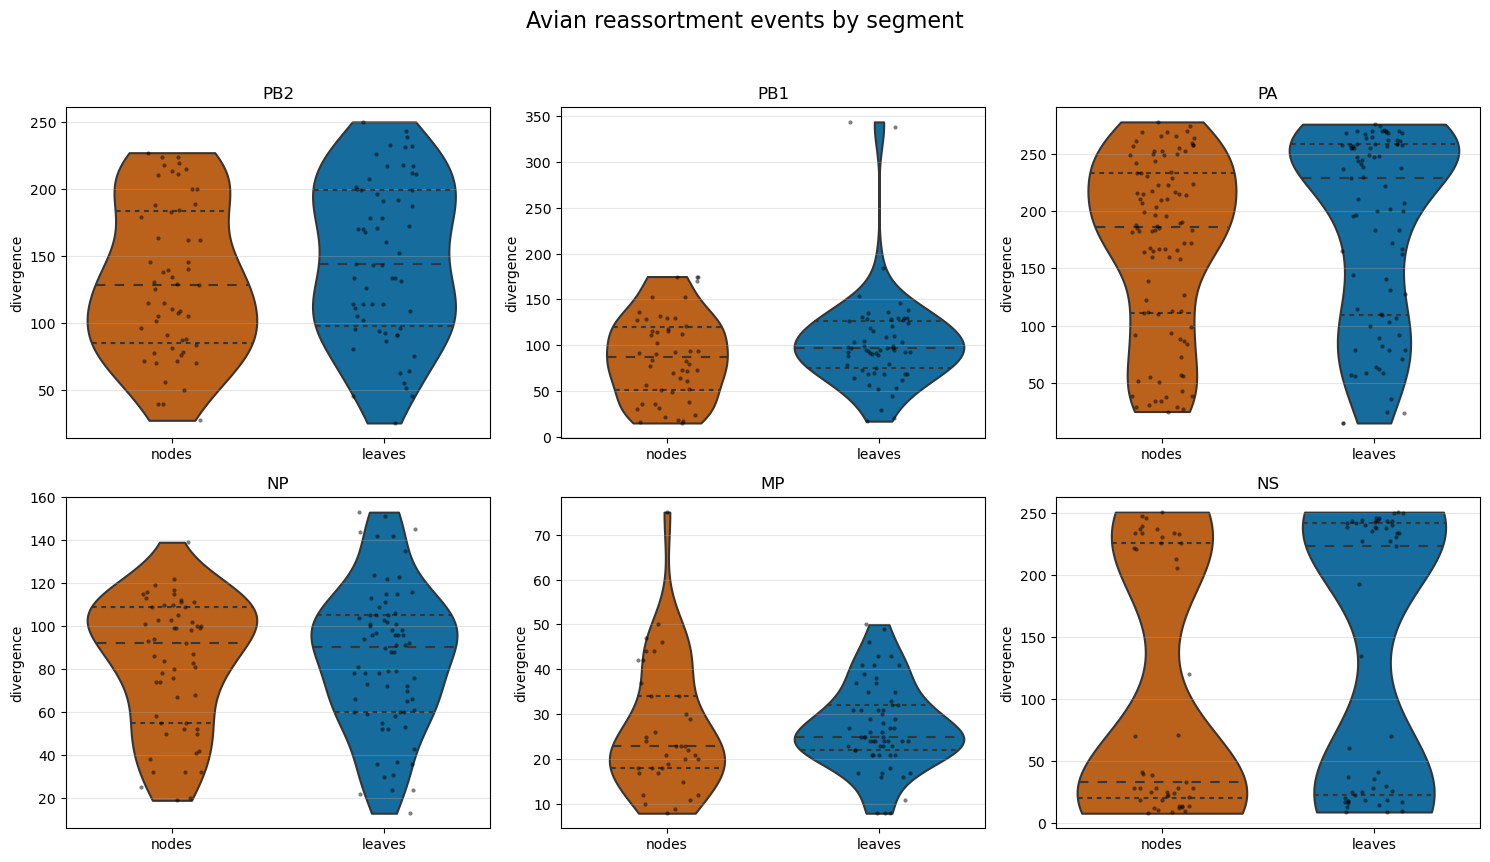

In [75]:
colors = {"leaf": "#0072B2", "node": "#D55E00"}

segments = list(segment_divs.keys())

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, seg in enumerate(segments):
    seg_dict = segment_divs[seg]

    df_seg = pd.DataFrame(list(seg_dict.items()), columns=["name", "divergence"])
    df_seg["type"] =df_seg["name"].apply(lambda x: "node" if x.startswith("NODE_") else "leaf")

    ax = axes[i]

    # violin plot
    sns.violinplot(
        x="type",
        y="divergence",
        data=df_seg,
        palette=colors,
        inner="quartile",
        cut=0,
        order=["node", "leaf"],
        ax=ax
    )

    # raw points
    sns.stripplot(
        x="type",
        y="divergence",
        data=df_seg,
        color="k",
        size=3,
        jitter=0.15,
        alpha=0.5,
        order=["node", "leaf"],
        ax=ax
    )

    ax.set_title(f"{seg}")
    ax.set_xlabel("")
    ax.set_ylabel("divergence")
    ax.set_xticklabels(["nodes", "leaves"])
    ax.grid(True, alpha=0.3, axis="y")

for j in range(len(segments), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Avian reassortment events by segment", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


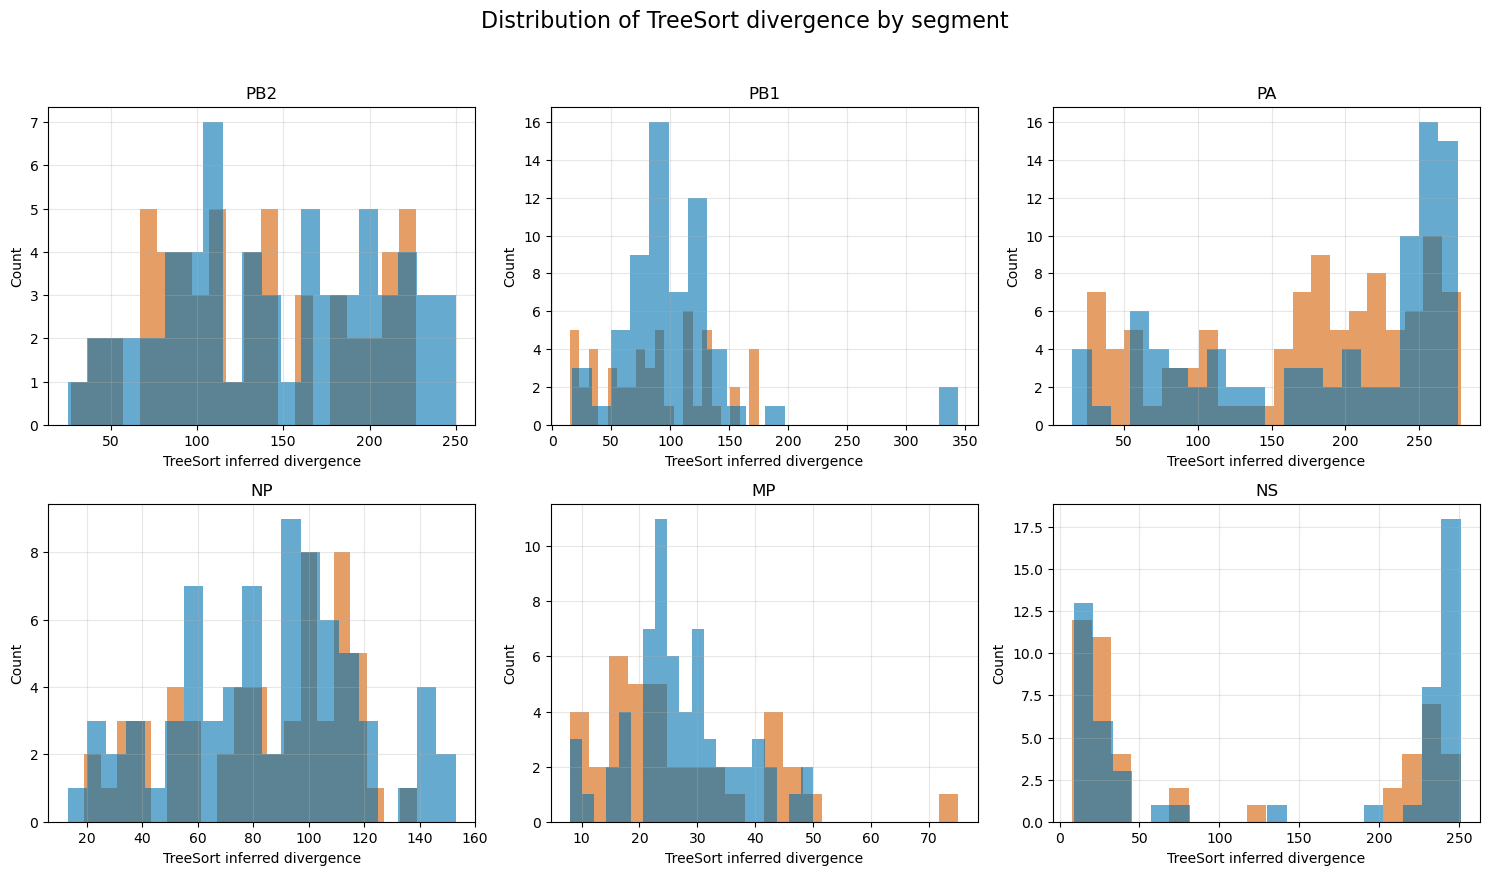

In [77]:
import matplotlib.pyplot as plt
import pandas as pd

colors = {"leaf": "#0072B2", "node": "#D55E00"}  # colorblind-friendly

segments = list(segment_divs.keys())

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, seg in enumerate(segments):
    seg_dict = segment_divs[seg]


    df_seg = pd.DataFrame(list(seg_dict.items()), columns=["name", "divergence"])
    df_seg["type"] = df_seg["name"].apply(lambda x: "node" if x.startswith("NODE_") else "leaf")

    ax = axes[i]

    ax.hist(
        df_seg.loc[df_seg["type"] == "node", "divergence"],
        bins=20,
        alpha=0.6,
        color=colors["node"],
        label="node"
    )

    ax.hist(
        df_seg.loc[df_seg["type"] == "leaf", "divergence"],
        bins=20,
        alpha=0.6,
        color=colors["leaf"],
        label="leaf"
    )

    ax.set_title(seg)
    ax.set_xlabel("TreeSort inferred divergence")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)


# remove any unused axes
for j in range(len(segments), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of TreeSort divergence by segment", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**how much divergence is there within and between avian NA subtypes?**



In [58]:
def fasta_to_df(fasta_file):
    
    fasta_data = []
    
    with open(fasta_file) as f:
        header = ""
        sequence = ""
        for line in f:
            if line.startswith(">"):
                if header != "":
                    fasta_data.append({"header": header, "sequence": sequence})
                header = line.strip() 
                sequence = ""
            else:
                sequence += line.strip()
        fasta_data.append({"header": header, "sequence": sequence}) #last line
            
    return pd.DataFrame(fasta_data)

def fasta_writer(path, filename, df):
            
    try:  
        os.mkdir(path)

    except OSError as error:
        pass

    with open(f"{path}{filename}", "w") as f:
        for index, row in df.iterrows():
            f.write(f"{row['header']}\n")
            f.write(f"{row['sequence']}\n")


In [59]:
def compute_divergence(seq1, seq2):
    """Return divergence between two aligned sequences"""
    
    s1 = np.frombuffer(seq1.encode("utf-8"), dtype='S1')
    s2 = np.frombuffer(seq2.encode("utf-8"), dtype='S1')

    valid = (
        (s1 != b'-') & (s2 != b'-') &
        (s1 != b'N') & (s2 != b'N') &
        (s1 != b'n') & (s2 != b'n')
    )

    n_valid = valid.sum()
        
    if n_valid == 0:
        return np.nan
    
    mismatches = np.sum((s1 != s2) & valid)
    return mismatches / n_valid


df1 = fasta_to_df("h3nx_na.fasta")
meta = pd.read_csv("metadata.csv")

df1["strain"] = df1["header"].str.lstrip(">")

df1 = df1.merge(meta, left_on="strain", right_on="strain", how="left")

exclude_strains = [
    "A/American_black_duck/Newfoundland/734/2008|2008-09-19",
    "A/mallard/Ohio/184/1986|1986-11-06",
    "A/blue-winged_teal/Guatemala/CIP049H102-32/2011|2011-11-11"
]

df1 = df1[~df1["strain"].isin(exclude_strains)]

records = []
for (i, row1), (j, row2) in itertools.combinations(df1.iterrows(), 2):
    
    div = compute_divergence(row1.sequence, row2.sequence)
    
    records.append({
        "strain1": row1.strain,
        "strain2": row2.strain,
        "subtype1": row1.subtype,
        "subtype2": row2.subtype,
        "divergence": div,
        "comparison": "within" if row1.subtype == row2.subtype else "between"
    })

div_df = pd.DataFrame(records)

/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


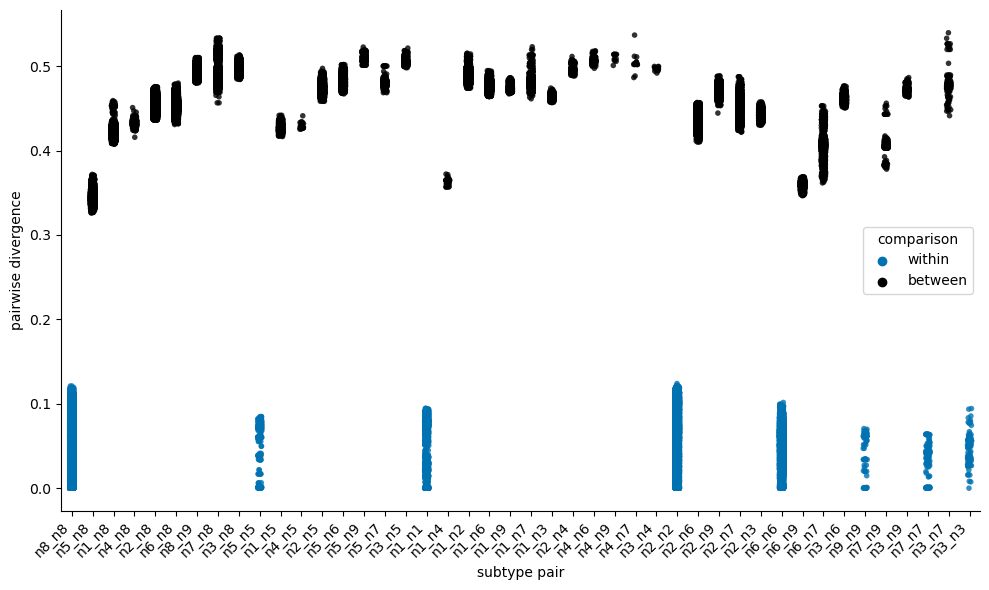

In [60]:
def make_pair(s1, s2):
    pair = "_".join(sorted([s1.replace("H3", "").lower(), s2.replace("H3", "").lower()]))
    return pair

div_df["subtype_pair"] = div_df.apply(lambda x: make_pair(x.subtype1, x.subtype2), axis=1)
div_df["comparison"] = div_df.apply(lambda x: "within" if x.subtype1 == x.subtype2 else "between", axis=1)


plt.figure(figsize=(10, 6))
sns.stripplot(
    data=div_df,
    x="subtype_pair",
    y="divergence",
    hue="comparison",
    dodge=False,
    palette={"within": "#0072B2", "between": "black"},
    alpha=0.8,
    size=4
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("subtype pair")
plt.ylabel("pairwise divergence")
sns.despine()
plt.tight_layout()
plt.show()


In [61]:
# now matching pairwise divergence units to treesort divergence values

def compute_divergence(seq1, seq2):
    
    s1 = np.frombuffer(seq1.encode("utf-8"), dtype='S1')
    s2 = np.frombuffer(seq2.encode("utf-8"), dtype='S1')

    valid = (
        (s1 != b'-') & (s2 != b'-') &
        (s1 != b'N') & (s2 != b'N') &
        (s1 != b'n') & (s2 != b'n')
    )

    n_valid = valid.sum()
        
    if n_valid == 0:
        return np.nan
    
    mismatches = np.sum((s1 != s2) & valid)
    return mismatches

df2 = fasta_to_df("h3nx_na.fasta")
meta = pd.read_csv("metadata.csv")

df2["strain"] = df2["header"].str.lstrip(">")
df2 = df2.merge(meta, left_on="strain", right_on="strain", how="left")

# mistyped strains
exclude_strains = [
    "A/American_black_duck/Newfoundland/734/2008|2008-09-19",
    "A/mallard/Ohio/184/1986|1986-11-06",
    "A/blue-winged_teal/Guatemala/CIP049H102-32/2011|2011-11-11"
]

df2 = df2[~df2["strain"].isin(exclude_strains)]

# need to filter out low quality sequences

df2["seq_len"] = df2["sequence"].str.len()

def count_valid_sites(seq):
    s = np.frombuffer(seq.encode("utf-8"), dtype='S1')
    valid = (s != b'-') & (s != b'N') & (s != b'n')
    return valid.sum()

df2["n_valid_sites"] = df2["sequence"].apply(count_valid_sites)

# maximum length per subtypes 
max_len_per_subtype = df2.groupby("subtype")["seq_len"].max().to_dict()

length_threshold = 0.8   # keep sequences ≥80% of max subtype length
valid_threshold = 0.8    # keep sequences with ≥80% valid sites relative to their length

df_filtered = df2[
    df2.apply(
        lambda row: (row.seq_len >= length_threshold * max_len_per_subtype[row.subtype]) and
                    (row.n_valid_sites / row.seq_len >= valid_threshold),
        axis=1
    )
]

records = []
for (i, row1), (j, row2) in itertools.combinations(df_filtered.iterrows(), 2):
    div = compute_divergence(row1.sequence, row2.sequence)
    records.append({
        "strain1": row1.strain,
        "strain2": row2.strain,
        "subtype1": row1.subtype,
        "subtype2": row2.subtype,
        "divergence": div,
        "comparison": "within" if row1.subtype == row2.subtype else "between"
    })

div_df1 = pd.DataFrame(records)


In [62]:
removed_df = df2[~df2["strain"].isin(df_filtered["strain"])]

if removed_df.empty:
    print("No sequences were removed after filtering.")
else:
    removed_counts = removed_df.groupby("subtype").size()
    print("Sequences removed per subtype:")
    for subtype, count in removed_counts.items():
        print(f"{subtype}: {count}")
        
num_pairs = len(div_df1)
print(f"Total pairwise comparisons: {num_pairs}")

Sequences removed per subtype:
H3N2: 1
H3N7: 3
H3N8: 1
Total pairwise comparisons: 702705


/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


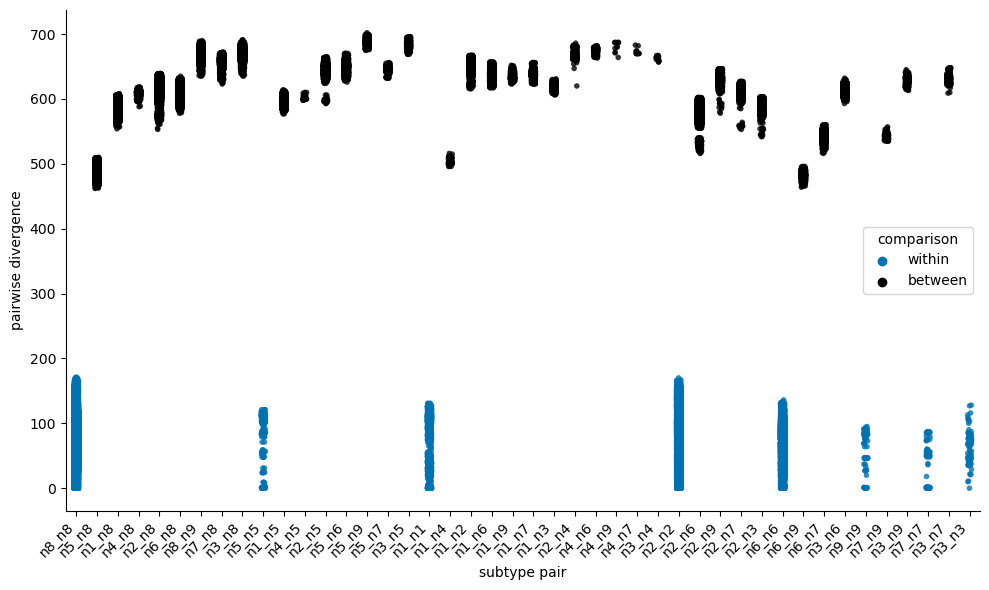

In [63]:
div_df1["subtype_pair"] = div_df1.apply(lambda x: make_pair(x.subtype1, x.subtype2), axis=1)
div_df1["comparison"] = div_df1.apply(lambda x: "within" if x.subtype1 == x.subtype2 else "between", axis=1)


plt.figure(figsize=(10, 6))
sns.stripplot(
    data=div_df1,
    x="subtype_pair",
    y="divergence",
    hue="comparison",
    dodge=False,
    palette={"within": "#0072B2", "between": "black"},
    alpha=0.8,
    size=4
)

# plt.axhline(within_cutoff, color='#0072B2', linestyle='--', linewidth=2, label='within cutoff')
# plt.axhline(between_cutoff, color='black', linestyle='--', linewidth=2, label='between cutoff')

plt.xticks(rotation=45, ha="right")
plt.xlabel("subtype pair")
plt.ylabel("pairwise divergence")
sns.despine()
plt.tight_layout()
plt.savefig("plots/rea_events_div_cutoffs.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [81]:
# calcualting cuttoffs based on min/max

within_cutoff = div_df1.loc[div_df1["comparison"]=="within", "divergence"].max()
between_cutoff = div_df1.loc[div_df1["comparison"]=="between", "divergence"].min()

print(f"Lower cutoff (within): {within_cutoff}")
print(f"Upper cutoff (between): {between_cutoff}")

Lower cutoff (within): 171
Upper cutoff (between): 462


/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/monclalab1/anaconda3/lib/python3.10/site-packages/seaborn/_

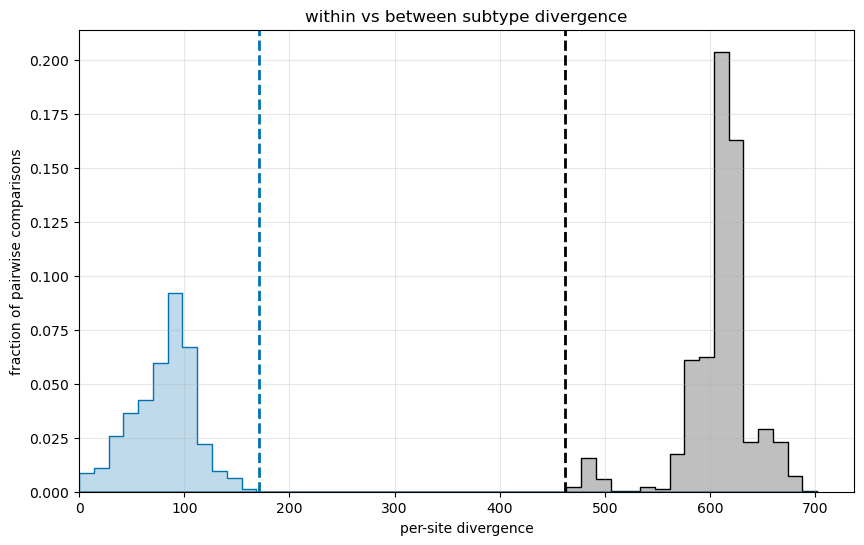

In [86]:
plt.figure(figsize=(10, 6))

palette = {"within": "#0072B2", "between": "black"}

sns.histplot(
    data=div_df1,
    x="divergence",
    hue="comparison",
    bins=50,
    stat="probability", # scales y-axis to fraction of total comparisons
    element="step",
    palette=palette 
)

plt.xlim(left=0)

# vertical dashed lines for global cutoffs
plt.axvline(within_cutoff, color='#0072B2', linestyle='--', linewidth=2, label='within-subtype cutoff')
plt.axvline(between_cutoff, color='black', linestyle='--', linewidth=2, label='between-subtype cutoff')

plt.xlabel("per-site divergence")
plt.ylabel("fraction of pairwise comparisons")
plt.title("within vs between subtype divergence")
plt.legend().set_visible(False)
plt.grid(alpha=0.3)
plt.savefig("plots/pairwise_div_cutoffs_histo.pdf", dpi=300, bbox_inches="tight")
plt.show()


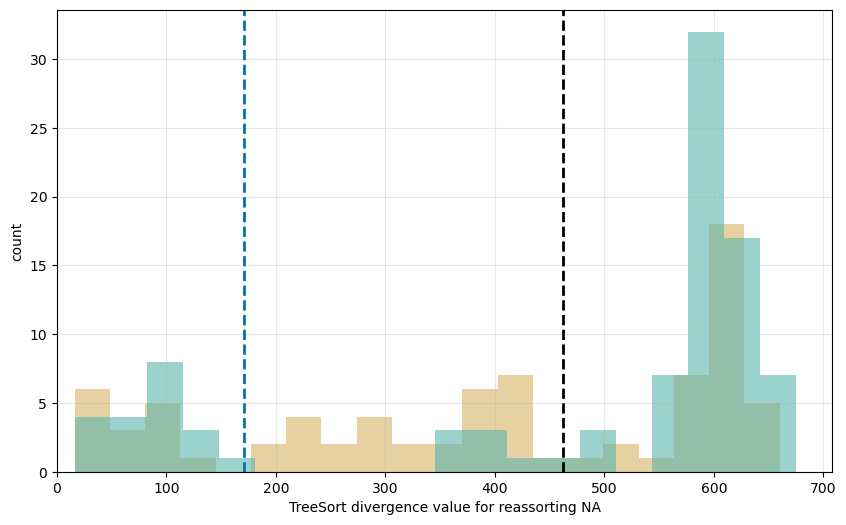

In [85]:
colors = {"leaf": "#5ab4ac", "node": "#d8b365"}

plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df['type'] == 'node', 'divergence'],
    bins=20,
    alpha=0.6,
    color=colors['node'],
    label='node'
)

plt.hist(
    df.loc[df['type'] == 'leaf', 'divergence'],
    bins=20,
    alpha=0.6,
    color=colors['leaf'],
    label='leaf'
)

# cutoffs calculated above
plt.axvline(within_cutoff, color='#0072B2', linestyle='--', linewidth=2, label='within-subtype')
plt.axvline(between_cutoff, color='black', linestyle='--', linewidth=2, label='between-subtype')

plt.xlim(left=0)
plt.xlabel("TreeSort divergence value for reassorting NA")
plt.ylabel("count")
# plt.legend()
plt.grid(alpha=0.3)
plt.savefig("plots/rea_events_leaf-node_div_cutoffs.pdf", dpi=300, bbox_inches="tight")
plt.show()



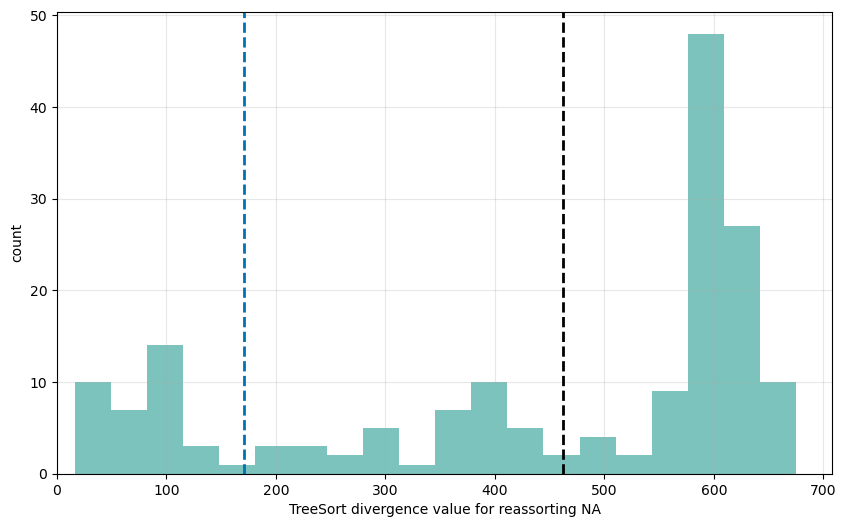

In [84]:
# not separating by leaf/node for presentations

plt.figure(figsize=(10, 6))


plt.hist(
    df['divergence'],
    bins=20,
    alpha=0.8,
    color="#5ab4ac"
)

# cutoffs
plt.axvline(within_cutoff, color='#0072B2', linestyle='--', linewidth=2, label='within-subtype')
plt.axvline(between_cutoff, color='black', linestyle='--', linewidth=2, label='between-subtype')

plt.xlim(left=0)
plt.xlabel("TreeSort divergence value for reassorting NA")
plt.ylabel("count")
plt.grid(alpha=0.3)

plt.savefig("plots/rea_events_div_cutoffs.pdf", dpi=300, bbox_inches="tight")
plt.show()
